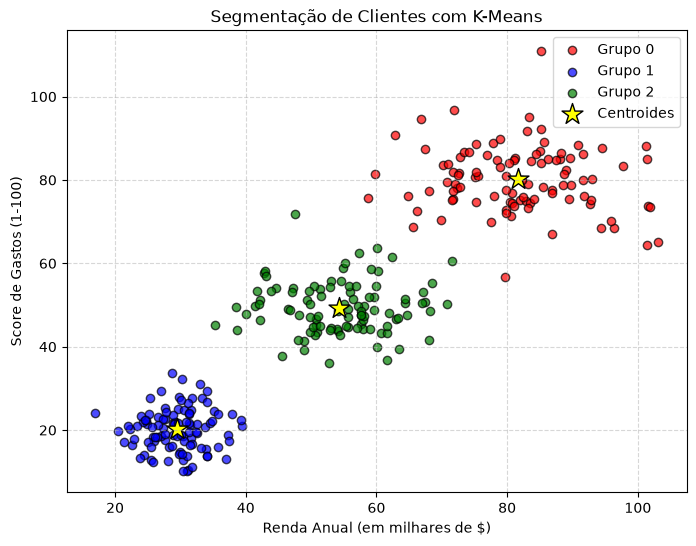

In [1]:
# 1. Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Configurando dados aleatórios realistas
np.random.seed(42)

# Simulando 3 grupos claros de clientes para testar o algoritmo
grupo1 = np.random.normal(loc=[30, 20], scale=[5, 5], size=(100, 2))  # Renda baixa, gasto baixo
grupo2 = np.random.normal(loc=[80, 80], scale=[10, 8], size=(100, 2)) # Renda alta, gasto alto
grupo3 = np.random.normal(loc=[55, 50], scale=[8, 6], size=(100, 2))  # Renda média, gasto médio

dados_clientes = np.vstack([grupo1, grupo2, grupo3])
df_clientes = pd.DataFrame(dados_clientes, columns=['Renda_Anual_Milhares', 'Score_Gastos'])

# 2. Criar e treinar o modelo K-Means
# Vamos pedir para ele encontrar exatamente 3 grupos (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clientes['Grupo'] = kmeans.fit_predict(df_clientes)

# 3. Plotar os resultados de forma visual e colorida
plt.figure(figsize=(8, 6))
cores = ['red', 'blue', 'green']

for grupo in range(3):
    componentes = df_clientes[df_clientes['Grupo'] == grupo]
    plt.scatter(componentes['Renda_Anual_Milhares'], componentes['Score_Gastos'], 
                c=cores[grupo], label=f'Grupo {grupo}', alpha=0.7, edgecolors='black')

# Plotar os centroides (o "coração" de cada grupo)
centroides = kmeans.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], s=250, c='yellow', 
            marker='*', label='Centroides', edgecolors='black')

plt.title('Segmentação de Clientes com K-Means')
plt.xlabel('Renda Anual (em milhares de $)')
plt.ylabel('Score de Gastos (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

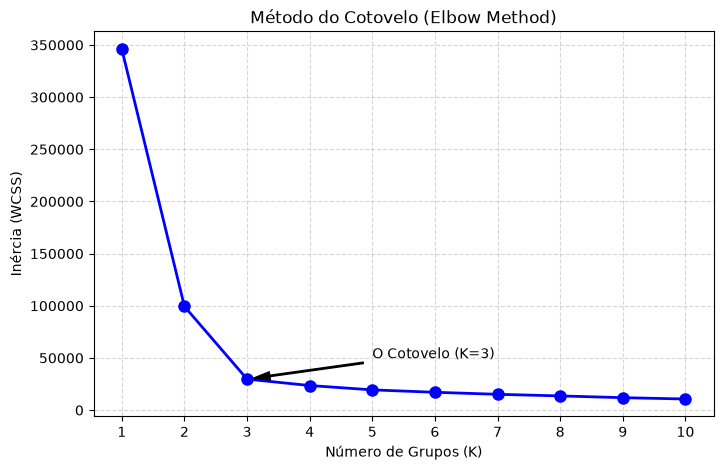

In [2]:
# 1. Criar uma lista para guardar os valores de Inércia (WCSS)
inercias = []

# 2. Testar o K-Means com diferentes quantidades de grupos (de 1 a 10)
valores_k = range(1, 11)

for k in valores_k:
    # Selecionamos apenas as colunas de dados originais (sem a coluna 'Grupo' que criamos antes)
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(df_clientes[['Renda_Anual_Milhares', 'Score_Gastos']])
    inercias.append(kmeans_teste.inertia_) # Guarda a inércia deste 'k'

# 3. Plotar o Gráfico do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, 'bo-', linewidth=2, markersize=8)
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Grupos (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.5)

# Destacar onde o "cotovelo" dobra (K=3)
plt.annotate('O Cotovelo (K=3)', xy=(3, inercias[2]), xytext=(5, inercias[2] + 20000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()